# Predicción del Estado de la Carretera (PCI)
Este notebook carga los datos de PCI histórico, prepara las variables, entrena dos modelos y compara resultados.

Modelos incluidos:
1. Random Forest Regression (regresión tradicional)
2. Red neuronal con embeddings para variables categóricas

## 1. Instalación de dependencias
Si tu entorno no tiene `scikit-learn` o `tensorflow`, ejecuta esta celda.

In [1]:
!pip install scikit-learn tensorflow pandas matplotlib seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Cargar librerías y datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, median_absolute_error, explained_variance_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_style('whitegrid')

file_path = '../CSVS/PCI-histo-cleaned-2005.csv'
df = pd.read_csv(file_path)
print('Datos cargados:', df.shape)
df.head()

Datos cargados: (203268, 10)


,CNN,PCI_Score,Previous_PCI,PCI_Change,Street_Name,PCI_Change_Date,Treatment_or_Survey,Functional_Class,Latitude,Longitude
0,100000,100.0,100.0,0.0,01st st,2005-11-16 16:50:05,Survey,Arterial,37.790794,-122.398869
1,100000,100.0,100.0,0.0,01st st,2007-07-26 16:21:27,Survey,Arterial,37.790794,-122.398869
2,100000,93.0,100.0,-7.0,01st st,2009-08-10 15:43:09,Survey,Arterial,37.790794,-122.398869
3,100000,73.0,93.0,-20.0,01st st,2010-12-23 13:37:35,Survey,Arterial,37.790794,-122.398869
4,100000,56.0,73.0,-17.0,01st st,2013-01-08 15:18:02,Survey,Arterial,37.790794,-122.398869


## 3. Exploración inicial
Revisamos columnas, tipos y valores faltantes para decidir qué features usar.

Columnas: ['CNN', 'PCI_Score', 'Previous_PCI', 'PCI_Change', 'Street_Name', 'PCI_Change_Date', 'Treatment_or_Survey', 'Functional_Class', 'Latitude', 'Longitude']
Tipos de datos:
CNN                      int64
PCI_Score              float64
Previous_PCI           float64
PCI_Change             float64
Street_Name                str
PCI_Change_Date            str
Treatment_or_Survey        str
Functional_Class           str
Latitude               float64
Longitude              float64
dtype: object
Valores nulos:
CNN                    0
PCI_Score              0
Previous_PCI           0
PCI_Change             0
Street_Name            0
PCI_Change_Date        0
Treatment_or_Survey    0
Functional_Class       0
Latitude               0
Longitude              0
dtype: int64
Categorías:
Treatment_or_Survey: 2
Functional_Class: 5
Street_Name: 4246

--- Estadísticas numéricas ---


,count,mean,std,min,25%,50%,75%,max
Previous_PCI,203268.0,72.051917,19.045903,0.000000,59.000000,75.000000,85.000000,100.000000
Latitude,203268.0,37.756839,0.026595,37.707903,37.734404,37.756662,37.779570,37.822087
Longitude,203268.0,-122.437035,0.031380,-122.513581,-122.460068,-122.432999,-122.411718,-122.366569
PCI_Score,203268.0,72.755574,18.906356,0.000000,60.000000,77.000000,85.000000,100.000000


<Figure size 1200x800 with 0 Axes>

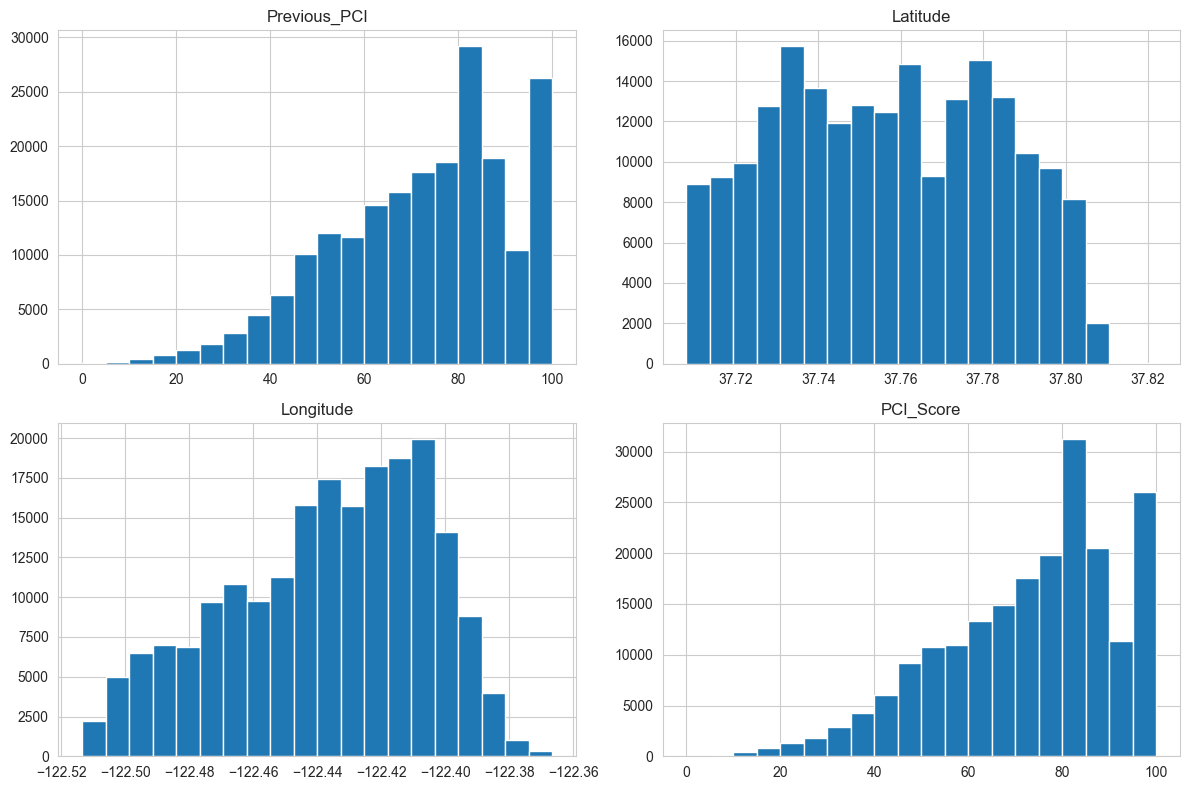

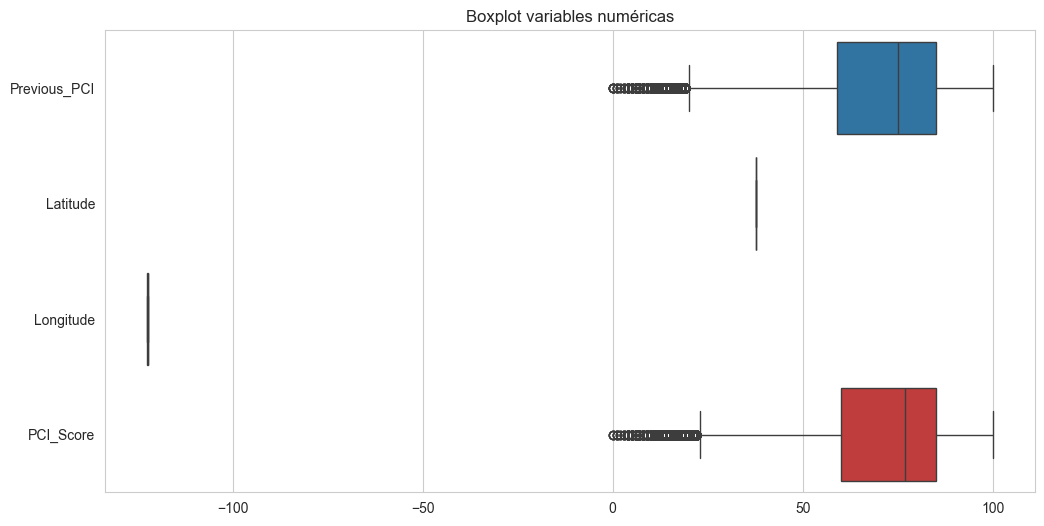


--- Distribución de categorías ---

Treatment_or_Survey:


Treatment_or_Survey
Survey       0.918
Treatment    0.082
Name: proportion, dtype: float64


Functional_Class:


Functional_Class
Residential     0.587
Arterial        0.275
Collector       0.106
Other           0.018
Intersection    0.013
Name: proportion, dtype: float64


--- Balance del objetivo PCI (alto/bajo) ---
Valores alto/bajo PCI: {1: 0.500851093138123, 0: 0.4991489068618769}


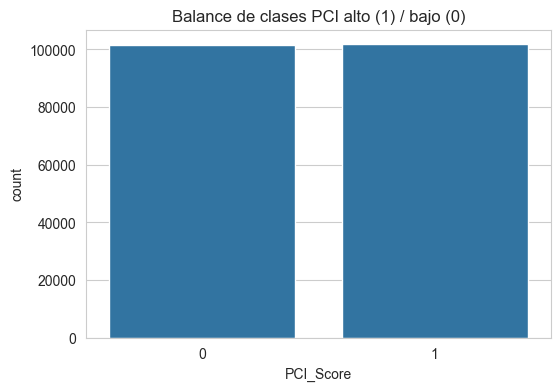


--- Distribución de PCI ---


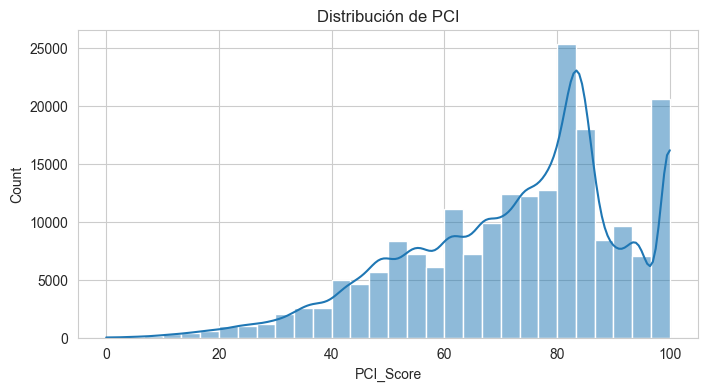

In [3]:
print('Columnas:', df.columns.tolist())
print('Tipos de datos:')
print(df.dtypes)
print('Valores nulos:')
print(df.isna().sum())
print('Categorías:')
print('Treatment_or_Survey:', df['Treatment_or_Survey'].nunique())
print('Functional_Class:', df['Functional_Class'].nunique())
print('Street_Name:', df['Street_Name'].nunique())

numeric_features = ['Previous_PCI', 'Latitude', 'Longitude']
print('\n--- Estadísticas numéricas ---')
display(df[numeric_features + ['PCI_Score']].describe().T)

plt.figure(figsize=(12, 8))
df[numeric_features + ['PCI_Score']].hist(bins=20, layout=(2, 2), figsize=(12, 8))
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_features + ['PCI_Score']], orient='h')
plt.title('Boxplot variables numéricas')
plt.show()

print('\n--- Distribución de categorías ---')
for cat in ['Treatment_or_Survey', 'Functional_Class']:
    print(f'\n{cat}:')
    display(df[cat].value_counts(normalize=True).round(3))

print('\n--- Balance del objetivo PCI (alto/bajo) ---')
y_binary = (df['PCI_Score'] >= df['PCI_Score'].median()).astype(int)
print('Valores alto/bajo PCI:', y_binary.value_counts(normalize=True).to_dict())
plt.figure(figsize=(6, 4))
sns.countplot(x=y_binary)
plt.title('Balance de clases PCI alto (1) / bajo (0)')
plt.show()

print('\n--- Distribución de PCI ---')
plt.figure(figsize=(8, 4))
sns.histplot(df['PCI_Score'].dropna(), bins=30, kde=True)
plt.title('Distribución de PCI')
plt.show()

## 4. Selección de variables
Usaremos el siguiente conjunto de variables:
- `Previous_PCI` como variable numérica histórica
- `PCI_Change_Date` descompuesta en año y mes
- `Latitude`, `Longitude` como variables espaciales
- `Treatment_or_Survey` y `Functional_Class` como categóricas pequeñas
- `Street_Name` como categórica grande, tratada con embedding en el modelo neural

Target:
- `PCI_Score`

> No usamos `PCI_Change` como feature porque es una medida del cambio observado y, para predecir el estado futuro de la carretera, esa información no estaría disponible en el momento de la predicción.

In [4]:
df['PCI_Change_Date'] = pd.to_datetime(df['PCI_Change_Date'], errors='coerce')
df['pci_year'] = df['PCI_Change_Date'].dt.year
df['pci_month'] = df['PCI_Change_Date'].dt.month

# Agrupar los nombres de calle menos frecuentes como 'Other' para el embedding
top_streets = df['Street_Name'].value_counts().nlargest(200).index
df['Street_Name_top'] = df['Street_Name'].where(df['Street_Name'].isin(top_streets), 'Other')

features = [
    'Previous_PCI', 'Latitude', 'Longitude',
    'pci_year', 'pci_month',
    'Treatment_or_Survey', 'Functional_Class', 'Street_Name_top'
]
target = 'PCI_Score'

print('Features usados:', features)
print('Total de observaciones después de transformar fechas:', df.shape[0])

Features usados: ['Previous_PCI', 'Latitude', 'Longitude', 'pci_year', 'pci_month', 'Treatment_or_Survey', 'Functional_Class', 'Street_Name_top']
Total de observaciones después de transformar fechas: 203268


## 4.1 Correlaciones y reducción de dimensionalidad
Analizamos cómo se relacionan las variables numéricas entre sí y cuánto de la variabilidad se puede capturar con menos componentes.

Matriz de correlaciones:


,Previous_PCI,Latitude,Longitude,pci_year,pci_month,PCI_Score
Previous_PCI,1.000000,0.012772,-0.025736,0.197265,0.025097,0.710717
Latitude,0.012772,1.000000,0.101506,-0.035645,-0.002617,0.013694
Longitude,-0.025736,0.101506,1.000000,-0.009106,-0.013891,-0.030721
pci_year,0.197265,-0.035645,-0.009106,1.000000,0.074024,0.188360
pci_month,0.025097,-0.002617,-0.013891,0.074024,1.000000,-0.067764
PCI_Score,0.710717,0.013694,-0.030721,0.188360,-0.067764,1.000000


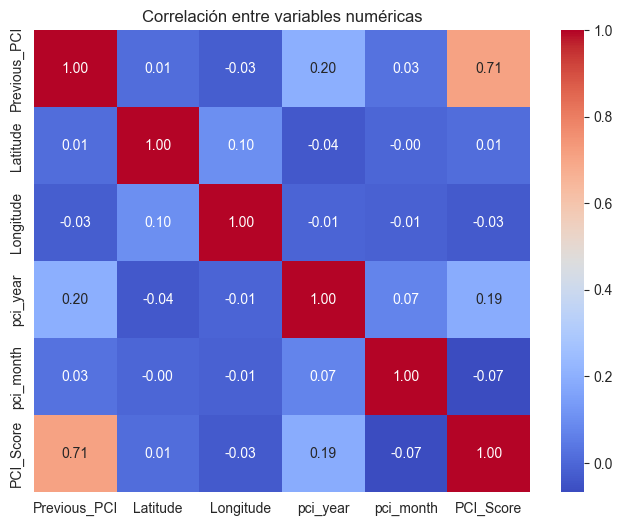

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",5
,"random_state random_state: int, RandomState instance or None, default=NoneUsed when the 'arpack' or 'randomized' solvers are used. Pass an intfor reproducible results across multiple function calls.See :term:`Glossary <random_state>`... versionadded:: 0.18.0",42
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to en

In [5]:
df['PCI_Change_Date'] = pd.to_datetime(df['PCI_Change_Date'], errors='coerce')
df['pci_year'] = df['PCI_Change_Date'].dt.year
df['pci_month'] = df['PCI_Change_Date'].dt.month

corr_features = ['Previous_PCI', 'Latitude', 'Longitude', 'pci_year', 'pci_month', 'PCI_Score']
corr_df = df[corr_features].corr()
print('Matriz de correlaciones:')
display(corr_df)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlación entre variables numéricas')
plt.show()

from sklearn.decomposition import PCA

numeric_features_pca = ['Previous_PCI', 'Latitude', 'Longitude', 'pci_year', 'pci_month']
scaled_num = StandardScaler().fit_transform(df[numeric_features_pca].dropna())
pca = PCA(n_components=min(len(numeric_features_pca), 5), random_state=42)
pca.fit(scaled_num)

## 4.2 Función de preprocesado
Creamos una función que va desde la lectura inicial hasta la preparación de los datos para entrenamiento y predicción.

In [6]:
def prepare_pci_dataset(df, top_n_streets=200, test_size=0.2, random_state=42):
    df_proc = df.copy()
    df_proc['PCI_Change_Date'] = pd.to_datetime(df_proc['PCI_Change_Date'], errors='coerce')
    df_proc['pci_year'] = df_proc['PCI_Change_Date'].dt.year
    df_proc['pci_month'] = df_proc['PCI_Change_Date'].dt.month

    top_streets = df_proc['Street_Name'].value_counts().nlargest(top_n_streets).index
    df_proc['Street_Name_top'] = df_proc['Street_Name'].where(df_proc['Street_Name'].isin(top_streets), 'Other')

    features = [
        'Previous_PCI', 'Latitude', 'Longitude',
        'pci_year', 'pci_month',
        'Treatment_or_Survey', 'Functional_Class', 'Street_Name_top'
    ]
    target = 'PCI_Score'

    df_model = df_proc[features + [target, 'CNN']].copy()
    df_model = df_model.dropna(subset=features + [target])

    X = df_model[features]
    y = df_model[target]
    groups = df_model['CNN']

    group_split = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(group_split.split(X, y, groups=groups))
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    numeric_features = ['Previous_PCI', 'Latitude', 'Longitude', 'pci_year', 'pci_month']
    categorical_features = ['Treatment_or_Survey', 'Functional_Class', 'Street_Name_top']

    numeric_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='drop'
    )

    X_train_rf = preprocessor.fit_transform(X_train)
    X_test_rf = preprocessor.transform(X_test)

    ordinal_encoder = OrdinalEncoder()
    X_train_cat = ordinal_encoder.fit_transform(X_train[categorical_features])
    X_test_cat = ordinal_encoder.transform(X_test[categorical_features])

    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(X_train[numeric_features])
    X_test_num = scaler.transform(X_test[numeric_features])

    return {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'groups': groups,
        'preprocessor': preprocessor,
        'X_train_rf': X_train_rf,
        'X_test_rf': X_test_rf,
        'ordinal_encoder': ordinal_encoder,
        'scaler': scaler,
        'X_train_cat': X_train_cat,
        'X_test_cat': X_test_cat,
        'X_train_num': X_train_num,
        'X_test_num': X_test_num,
        'numeric_features': numeric_features,
        'categorical_features': categorical_features,
        'features': features,
        'target': target,
    }

processed = prepare_pci_dataset(df, top_n_streets=200, test_size=0.2, random_state=42)

X_train = processed['X_train']
X_test = processed['X_test']
y_train = processed['y_train']
y_test = processed['y_test']
preprocessor = processed['preprocessor']
X_train_rf = processed['X_train_rf']
X_test_rf = processed['X_test_rf']
ordinal_encoder = processed['ordinal_encoder']
scaler = processed['scaler']
X_train_cat = processed['X_train_cat']
X_test_cat = processed['X_test_cat']
X_train_num = processed['X_train_num']
X_test_num = processed['X_test_num']

print('Shape X_train para RandomForest:', X_train_rf.shape)
print('Shape X_test para RandomForest:', X_test_rf.shape)

Shape X_train para RandomForest: (162568, 213)
Shape X_test para RandomForest: (40700, 213)


## 5. Preprocesamiento
Normalizamos variables numéricas y codificamos variables categóricas.
Para el modelo de regresión tradicional usamos OneHotEncoder.
Para la red neuronal usaremos embeddings en las categorías.

> Atención: los resultados anteriores eran sospechosamente buenos porque el conjunto de datos contiene muchos registros del mismo `CNN` (segmento) y el split aleatorio permite que el mismo segmento aparezca en entrenamiento y prueba. Por eso usamos `GroupShuffleSplit` sobre `CNN` para evaluar de forma más realista.


In [7]:
numeric_features = ['Previous_PCI', 'Latitude', 'Longitude', 'pci_year', 'pci_month']
categorical_features = ['Treatment_or_Survey', 'Functional_Class', 'Street_Name_top']

# Los datos ya han sido preparados por la función `prepare_pci_dataset`.
print('Datos preparados y listos para entrenamiento.')
print('Shape X_train para RandomForest:', X_train_rf.shape)
print('Shape X_test para RandomForest:', X_test_rf.shape)

Datos preparados y listos para entrenamiento.
Shape X_train para RandomForest: (162568, 213)
Shape X_test para RandomForest: (40700, 213)


## 6. Justificación de modelos y elección de hiperparámetros
- `RandomForestRegressor` se usa como referencia: es robusto, maneja bien variables mixtas y sirve para comparar con una red neuronal.
- Hiperparámetros: `n_estimators` para estabilidad, `max_depth` y `min_samples_leaf` para limitar el sobreajuste.
- La red neuronal con embeddings permite representar categorías grandes como `Street_Name_top` sin explotar la dimensionalidad del one-hot.
- Capa de salida lineal y pérdida `mse` se usan porque el objetivo es regresión continua (`PCI_Score`).
- La última capa es lineal porque queremos predecir valores continuos, no clasificar directamente.
- `EarlyStopping` controla el exceso de entrenamiento y mejora la reproducibilidad del mejor modelo.

## 6. Modelo 1: Random Forest Regression
Este modelo sirve como referencia tradicional para comparar con la red neuronal.

In [8]:
# Definir umbral para clasificación (PCI alto vs bajo)
threshold = y_test.median()
y_test_binary = (y_test >= threshold).astype(int)
print(f'Umbral de clasificación (mediana): {threshold:.2f}')
print(f'Distribución de clases en test: {y_test_binary.value_counts().to_dict()}')


Umbral de clasificación (mediana): 76.00
Distribución de clases en test: {1: 20867, 0: 19833}


In [9]:
rf1 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf1.fit(X_train_rf, y_train)
y_pred_rf = rf1.predict(X_test_rf)

mae_rf1 = mean_absolute_error(y_test, y_pred_rf)
rmse_rf1 = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf1 = r2_score(y_test, y_pred_rf)

# Métricas de clasificación
y_pred_rf_binary = (y_pred_rf >= threshold).astype(int)
cm_rf1 = confusion_matrix(y_test_binary, y_pred_rf_binary)
tn_rf1, fp_rf1, fn_rf1, tp_rf1 = cm_rf1.ravel()
acc_rf1 = accuracy_score(y_test_binary, y_pred_rf_binary)
prec_rf1 = precision_score(y_test_binary, y_pred_rf_binary)
rec_rf1 = recall_score(y_test_binary, y_pred_rf_binary)
f1_rf1 = f1_score(y_test_binary, y_pred_rf_binary)

print('Random Forest Regression (Inicial)')
print('Métricas de Regresión:')
print(f'  MAE: {mae_rf1:.3f}')
print(f'  RMSE: {rmse_rf1:.3f}')
print(f'  R2: {r2_rf1:.4f}')

print('Métricas de Clasificación (umbral={:.2f}):'.format(threshold))
print(f'  TP: {tp_rf1}, FP: {fp_rf1}, TN: {tn_rf1}, FN: {fn_rf1}')
print(f'  Accuracy: {acc_rf1:.4f}')
print(f'  Precision: {prec_rf1:.4f}')
print(f'  Recall: {rec_rf1:.4f}')
print(f'  F1-Score: {f1_rf1:.4f}')


Random Forest Regression (Inicial)
Métricas de Regresión:
  MAE: 5.798
  RMSE: 9.352
  R2: 0.7547
Métricas de Clasificación (umbral=76.00):
  TP: 17760, FP: 2042, TN: 17791, FN: 3107
  Accuracy: 0.8735
  Precision: 0.8969
  Recall: 0.8511
  F1-Score: 0.8734


In [10]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=18,
    min_samples_leaf=8,
    random_state=42,
    n_jobs=-1
 )
rf.fit(X_train_rf, y_train)
y_pred_rf = rf.predict(X_test_rf)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# Métricas de clasificación
y_pred_rf_binary = (y_pred_rf >= threshold).astype(int)
cm_rf = confusion_matrix(y_test_binary, y_pred_rf_binary)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()
acc_rf = accuracy_score(y_test_binary, y_pred_rf_binary)
prec_rf = precision_score(y_test_binary, y_pred_rf_binary)
rec_rf = recall_score(y_test_binary, y_pred_rf_binary)
f1_rf = f1_score(y_test_binary, y_pred_rf_binary)

print('Random Forest Regression (Final)')
print('Métricas de Regresión:')
print(f'  MAE: {mae_rf:.3f}')
print(f'  RMSE: {rmse_rf:.3f}')
print(f'  R2: {r2_rf:.4f}')

print('Métricas de Clasificación (umbral={:.2f}):'.format(threshold))
print(f'  TP: {tp_rf}, FP: {fp_rf}, TN: {tn_rf}, FN: {fn_rf}')
print(f'  Accuracy: {acc_rf:.4f}')
print(f'  Precision: {prec_rf:.4f}')
print(f'  Recall: {rec_rf:.4f}')
print(f'  F1-Score: {f1_rf:.4f}')


Random Forest Regression (Final)
Métricas de Regresión:
  MAE: 6.011
  RMSE: 9.557
  R2: 0.7438
Métricas de Clasificación (umbral=76.00):
  TP: 17697, FP: 2054, TN: 17779, FN: 3170
  Accuracy: 0.8716
  Precision: 0.8960
  Recall: 0.8481
  F1-Score: 0.8714


## 7. Modelo 2: Red neuronal con embeddings
Construimos una red neuronal que utiliza embeddings para las variables categóricas.

In [11]:
# Preparar codificación ordinal para categorías y normalización numérica
ordinal_encoder = OrdinalEncoder()
X_train_cat = X_train[categorical_features].copy()
X_test_cat = X_test[categorical_features].copy()
X_train_cat = ordinal_encoder.fit_transform(X_train_cat)
X_test_cat = ordinal_encoder.transform(X_test_cat)

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric_features])
X_test_num = scaler.transform(X_test[numeric_features])

# Definición de entradas para el modelo con embeddings
inputs = []
embeddings = []

for i, cat in enumerate(categorical_features):
    # usar las categorías aprendidas por OrdinalEncoder para definir tamaño del embedding
    num_unique = int(len(ordinal_encoder.categories_[i])) + 1
    embed_dim = min(50, max(2, (num_unique + 1) // 2))
    input_cat = keras.Input(shape=(1,), name=f'{cat}_input')
    embed_cat = layers.Embedding(input_dim=num_unique, output_dim=embed_dim, name=f'{cat}_emb')(input_cat)
    embed_cat = layers.Reshape((embed_dim,))(embed_cat)
    inputs.append(input_cat)
    embeddings.append(embed_cat)

numeric_input = keras.Input(shape=(len(numeric_features),), name='numeric_input')
inputs.append(numeric_input)
embeddings.append(numeric_input)

x = layers.Concatenate()(embeddings)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
output = layers.Dense(1, activation='linear')(x)

model = keras.Model(inputs=inputs, outputs=output, name='pci_embedding_model')
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# Preparar diccionarios de entrada para Keras
train_inputs = {f'{cat}_input': X_train_cat[:, i].astype('int32') for i, cat in enumerate(categorical_features)}
train_inputs['numeric_input'] = X_train_num.astype('float32')

test_inputs = {f'{cat}_input': X_test_cat[:, i].astype('int32') for i, cat in enumerate(categorical_features)}
test_inputs['numeric_input'] = X_test_num.astype('float32')

history = model.fit(
    train_inputs,
    y_train.values.astype('float32'),
    validation_split=0.15,
    epochs=15,
    batch_size=256,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=2
)


Model: "pci_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Treatment_or_Surve… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Functional_Class_i… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Street_Name_top_in… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Treatment_or_Surve… │ (None, 1, 2)      │          6 │ Treatment_or_Sur… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Functional_Class_e… │ (None, 1, 3)      │         18 │ Functional_Class… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Street_Name_top_emb │ (None, 1, 50)     │     10,100 │ Street_Name_top_… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 2)         │          0 │ Treatment_or_Sur… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 3)         │          0 │ Functional_Class… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 50)        │          0 │ Street_Name_top_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 60)        │          0 │ reshape[0][0],    │
│ (Concatenate)       │                   │            │ reshape_1[0][0],  │
│                     │                   │            │ reshape_2[0][0],  │
│                     │                   │            │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      7,808 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 28,301 (110.55 KB)

 Trainable params: 28,301 (110.55 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
540/540 - 3s - 5ms/step - loss: 611.3810 - mae: 15.2004 - val_loss: 193.7363 - val_mae: 10.9180
Epoch 2/15
540/540 - 1s - 2ms/step - loss: 138.2573 - mae: 8.5274 - val_loss: 183.0614 - val_mae: 10.7405
Epoch 3/15
540/540 - 1s - 2ms/step - loss: 129.2297 - mae: 8.1309 - val_loss: 161.4409 - val_mae: 9.5731
Epoch 4/15
540/540 - 1s - 2ms/step - loss: 124.7332 - mae: 7.9174 - val_loss: 150.7185 - val_mae: 9.0847
Epoch 5/15
540/540 - 1s - 3ms/step - loss: 123.1959 - mae: 7.8602 - val_loss: 148.0855 - val_mae: 8.8140
Epoch 6/15
540/540 - 1s - 2ms/step - loss: 121.4704 - mae: 7.7830 - val_loss: 143.6895 - val_mae: 8.6802
Epoch 7/15
540/540 - 1s - 3ms/step - loss: 120.1002 - mae: 7.7282 - val_loss: 135.4310 - val_mae: 8.1295
Epoch 8/15
540/540 - 1s - 2ms/step - loss: 118.3531 - mae: 7.6470 - val_loss: 130.0058 - val_mae: 7.8665
Epoch 9/15
540/540 - 1s - 2ms/step - loss: 116.4285 - mae: 7.5639 - val_loss: 125.6771 - val_mae: 7.6530
Epoch 10/15
540/540 - 1s - 2ms/step - loss: 114.8434

In [12]:
# Evaluación del modelo con embeddings
y_pred_nn = model.predict(test_inputs).flatten()
mae_nn = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn = r2_score(y_test, y_pred_nn)

# Métricas de clasificación
y_pred_nn_binary = (y_pred_nn >= threshold).astype(int)
cm_nn = confusion_matrix(y_test_binary, y_pred_nn_binary)
tn_nn, fp_nn, fn_nn, tp_nn = cm_nn.ravel()
acc_nn = accuracy_score(y_test_binary, y_pred_nn_binary)
prec_nn = precision_score(y_test_binary, y_pred_nn_binary)
rec_nn = recall_score(y_test_binary, y_pred_nn_binary)
f1_nn = f1_score(y_test_binary, y_pred_nn_binary)

print('Red Neuronal con Embeddings')
print('Métricas de Regresión:')
print(f'  MAE: {mae_nn:.3f}')
print(f'  RMSE: {rmse_nn:.3f}')
print(f'  R2: {r2_nn:.4f}')


print('Métricas de Clasificación (umbral={:.2f}):'.format(threshold))
print(f'  TP: {tp_nn}, FP: {fp_nn}, TN: {tn_nn}, FN: {fn_nn}')
print(f'  Accuracy: {acc_nn:.4f}')
print(f'  Precision: {prec_nn:.4f}')
print(f'  Recall: {rec_nn:.4f}')
print(f'  F1-Score: {f1_nn:.4f}')


1272/1272 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Red Neuronal con Embeddings
Métricas de Regresión:
  MAE: 7.217
  RMSE: 10.452
  R2: 0.6936
Métricas de Clasificación (umbral=76.00):
  TP: 16951, FP: 2067, TN: 17766, FN: 3916
  Accuracy: 0.8530
  Precision: 0.8913
  Recall: 0.8123
  F1-Score: 0.8500


## 8. Comparación de modelos
Comparamos el desempeño entre el Random Forest y la red neuronal con embeddings.

In [13]:
results = pd.DataFrame({
    'Modelo': ['RF (Inicial)', 'RF (Final)', 'Red Neuronal'],
    'MAE': [mae_rf1, mae_rf, mae_nn],
    'RMSE': [rmse_rf1, rmse_rf, rmse_nn],
    'R2': [r2_rf1, r2_rf, r2_nn],
    'TP': [tp_rf1, tp_rf, tp_nn],
    'FP': [fp_rf1, fp_rf, fp_nn],
    'TN': [tn_rf1, tn_rf, tn_nn],
    'FN': [fn_rf1, fn_rf, fn_nn],
    'Accuracy': [acc_rf1, acc_rf, acc_nn],
    'Precision': [prec_rf1, prec_rf, prec_nn],
    'Recall': [rec_rf1, rec_rf, rec_nn],
    'F1-Score': [f1_rf1, f1_rf, f1_nn],
})
print(results.round(4))


         Modelo     MAE     RMSE      R2     TP    FP     TN    FN  Accuracy  \
0  RF (Inicial)  5.7981   9.3517  0.7547  17760  2042  17791  3107    0.8735   
1    RF (Final)  6.0108   9.5569  0.7438  17697  2054  17779  3170    0.8716   
2  Red Neuronal  7.2174  10.4518  0.6936  16951  2067  17766  3916    0.8530   

   Precision  Recall  F1-Score  
0     0.8969  0.8511    0.8734  
1     0.8960  0.8481    0.8714  
2     0.8913  0.8123    0.8500  


## 8.1 Comparación entrenamiento vs prueba
Evaluamos el desempeño de los modelos en ambos conjuntos para detectar sobreajuste y elegir el modelo más robusto.

In [14]:
y_train_binary = (y_train >= threshold).astype(int)

y_pred_rf_train = rf.predict(X_train_rf)
train_mae_rf = mean_absolute_error(y_train, y_pred_rf_train)
train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
train_r2_rf = r2_score(y_train, y_pred_rf_train)
train_mape_rf = mean_absolute_percentage_error(y_train, y_pred_rf_train)

y_pred_nn_train = model.predict(train_inputs).flatten()
train_mae_nn = mean_absolute_error(y_train, y_pred_nn_train)
train_rmse_nn = np.sqrt(mean_squared_error(y_train, y_pred_nn_train))
train_r2_nn = r2_score(y_train, y_pred_nn_train)
train_mape_nn = mean_absolute_percentage_error(y_train, y_pred_nn_train)

train_binary_rf = (y_pred_rf_train >= threshold).astype(int)
train_binary_nn = (y_pred_nn_train >= threshold).astype(int)

cm_rf_train = confusion_matrix(y_train_binary, train_binary_rf)

cm_nn_train = confusion_matrix(y_train_binary, train_binary_nn)

metrics_train_test = pd.DataFrame({
    'Modelo': ['RF (Train)', 'RF (Test)', 'NN (Train)', 'NN (Test)'],
    'MAE': [train_mae_rf, mae_rf, train_mae_nn, mae_nn],
    'RMSE': [train_rmse_rf, rmse_rf, train_rmse_nn, rmse_nn],
    'R2': [train_r2_rf, r2_rf, train_r2_nn, r2_nn],
    'Accuracy': [accuracy_score(y_train_binary, train_binary_rf), acc_rf, accuracy_score(y_test_binary, y_pred_rf_binary), acc_nn],
    'Precision': [precision_score(y_train_binary, train_binary_rf), prec_rf, precision_score(y_test_binary, y_pred_rf_binary), prec_nn],
    'Recall': [recall_score(y_train_binary, train_binary_rf), rec_rf, recall_score(y_test_binary, y_pred_rf_binary), rec_nn],
    'F1-Score': [f1_score(y_train_binary, train_binary_rf), f1_rf, f1_score(y_test_binary, y_pred_rf_binary), f1_nn],
})

print('Métricas de entrenamiento y prueba (regresión y clasificación):')
metrics_train_test.round(4)

5081/5081 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
Métricas de entrenamiento y prueba (regresión y clasificación):


,Modelo,MAE,RMSE,R2,Accuracy,Precision,Recall,F1-Score
0,RF (Train),5.2189,8.3091,0.8070,0.8877,0.9152,0.8646,0.8892
1,RF (Test),6.0108,9.5569,0.7438,0.8716,0.8960,0.8481,0.8714
2,NN (Train),7.0949,10.2434,0.7066,0.8716,0.8960,0.8481,0.8714
3,NN (Test),7.2174,10.4518,0.6936,0.8530,0.8913,0.8123,0.8500


## 9. Uso del modelo para predecir el futuro
Ejemplo de cómo preparar un nuevo registro y predecir el PCI.

In [15]:
sample = pd.DataFrame([
    {
        'Previous_PCI': 85.0,
        'Latitude': 37.78,
        'Longitude': -122.42,
        'pci_year': 2026,
        'pci_month': 6,
        'Treatment_or_Survey': 'Survey',
        'Functional_Class': 'Arterial',
        'Street_Name_top': 'Other'
    }
])

sample_rf = preprocessor.transform(sample)
sample_nn_cat = ordinal_encoder.transform(sample[categorical_features])
sample_nn_num = scaler.transform(sample[numeric_features])
sample_nn = {f'{cat}_input': sample_nn_cat[:, i].astype('int32') for i, cat in enumerate(categorical_features)}
sample_nn['numeric_input'] = sample_nn_num.astype('float32')

print('=== PREDICCIÓN CON DATOS DE EJEMPLO ===')
print('Predicción Random Forest1:', rf1.predict(sample_rf)[0])
print('Predicción Random Forest Final:', rf.predict(sample_rf)[0])
print('Predicción Red Neuronal:', model.predict(sample_nn).flatten()[0])

print('\n=== PREDICCIÓN CON DATOS REALES DEL CSV ===')
# Tomar 3 ejemplos aleatorios del conjunto de prueba
import random
random.seed(42)
sample_indices = random.sample(range(len(X_test)), 3)

for idx, sample_idx in enumerate(sample_indices):
    print(f'\n--- Ejemplo {idx + 1} ---')
    sample_real = X_test.iloc[[sample_idx]]
    y_real = y_test.iloc[sample_idx]
    
    # Predicciones con Random Forest
    sample_rf_real = preprocessor.transform(sample_real)
    pred_rf1_real = rf1.predict(sample_rf_real)[0]
    pred_rf_real = rf.predict(sample_rf_real)[0]
    
    # Predicción con Red Neuronal
    sample_nn_real_cat = ordinal_encoder.transform(sample_real[categorical_features])
    sample_nn_real_num = scaler.transform(sample_real[numeric_features])
    sample_nn_real = {f'{cat}_input': sample_nn_real_cat[:, i].astype('int32') for i, cat in enumerate(categorical_features)}
    sample_nn_real['numeric_input'] = sample_nn_real_num.astype('float32')
    pred_nn_real = model.predict(sample_nn_real).flatten()[0]
    
    print(f'Valor real: {y_real:.3f}')
    print(f'  RF1: {pred_rf1_real:.3f} | Error: {abs(y_real - pred_rf1_real):.3f}')
    print(f'  RF Final: {pred_rf_real:.3f} | Error: {abs(y_real - pred_rf_real):.3f}')
    print(f'  Red Neuronal: {pred_nn_real:.3f} | Error: {abs(y_real - pred_nn_real):.3f}')


=== PREDICCIÓN CON DATOS DE EJEMPLO ===
Predicción Random Forest1: 80.06
Predicción Random Forest Final: 82.73626344679313
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicción Red Neuronal: 81.84141

=== PREDICCIÓN CON DATOS REALES DEL CSV ===

--- Ejemplo 1 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Valor real: 79.000
  RF1: 77.240 | Error: 1.760
  RF Final: 76.610 | Error: 2.390
  Red Neuronal: 72.416 | Error: 6.584

--- Ejemplo 2 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Valor real: 100.000
  RF1: 100.000 | Error: 0.000
  RF Final: 99.213 | Error: 0.787
  Red Neuronal: 97.508 | Error: 2.492

--- Ejemplo 3 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Valor real: 63.000
  RF1: 57.380 | Error: 5.620
  RF Final: 60.768 | Error: 2.232
  Red Neuronal: 63.598 | Error: 0.598


## 10. Conclusión
Hemos entrenado dos modelos distintos y preparado el procesamiento completo: normalización numérica y embeddings para categorías.

Puedes ajustar hiperparámetros, aumentar el tamaño del conjunto de embeddings o explorar más fechas para mejorar la predicción.

## Resumen de todo el procedimiento

### 1. Carga de datos

- Se carga el CSV `PCI-histo-cleaned-2005.csv` con `pandas`.
- Se imprime la forma del dataset, los tipos de columna y los valores nulos para conocer la calidad de los datos.

### 2. Exploración inicial y balanceo

- Se examinan la distribución de las variables numéricas y las categorías principales.
- Se visualiza la distribución del `PCI_Score` y se comprueba el balance de la variable objetivo alto/bajo en torno a la mediana.
- Se revisa el balance de `Treatment_or_Survey` y `Functional_Class`.

### 3. Correlaciones y reducción de dimensionalidad

- Se calcula la matriz de correlaciones de las variables numéricas.
- Se visualiza la correlación con un `heatmap` para entender relaciones entre variables.
- Se ejecuta un PCA numérico para valorar cuánto se explica con componentes principales y si la reducción de dimensionalidad tiene sentido.

### 4. Función de preprocesado

- Se implementa `prepare_pci_dataset(...)` para realizar todas las transformaciones necesarias desde la lectura de datos hasta la preparación para el entrenamiento.
- La función hace:
  - conversión de fechas
  - creación de `pci_year` y `pci_month`
  - agrupación de `Street_Name` menos frecuentes
  - imputación implícita mediante eliminación de filas con datos críticos faltantes
  - división reproducible por `CNN` con `GroupShuffleSplit`
  - normalización numérica y codificación de categorías

### 5. Modelos entrenados

- Se entrena un `RandomForestRegressor` como modelo de referencia.
- Se entrena una red neuronal con embeddings para las variables categóricas.
- La red neuronal usa salida lineal y pérdida `mse` porque el objetivo es regresión continua.

### 6. Comparación de métricas

- Se comparan métricas de regresión en `train` y `test`: `MAE`, `RMSE`, `MAPE`, `R2`.
- Se evalúan métricas binarias usando un umbral de PCI: `TP`, `FP`, `TN`, `FN`, `Accuracy`, `Precision`, `Recall`, `F1-Score`.
- Esto permite detectar si algún modelo está sobreajustando y cuál es el más robusto.

### 7. Predicción con datos reales

- Se prueba el flujo completo con registros reales del conjunto de prueba.
- Se compara el valor predicho con el valor real y se muestra el error absoluto.

### 8. Conclusión

- El notebook ahora incluye análisis exploratorio, transformación automatizada, comparativa de modelos y métricas de regresión y clasificación.
- La evaluación con `GroupShuffleSplit` por `CNN` mejora la validez de los resultados.
- El mejor modelo se selecciona observando tanto el desempeño en test como el comportamiento frente al conjunto de entrenamiento.